In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
file_path = '../datasets/dataset_train.csv'
df = pd.read_csv(file_path)

In [104]:
data = df.copy()

In [105]:
sns.set(style='darkgrid')

In [106]:
courses = data.columns[6:]

In [107]:
std = data.groupby('Hogwarts House')[courses].std()
std

,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
Hogwarts House,,,,,,,,,,,,,
Gryffindor,15192.509158,195.613259,2.252714,1.951571,1.454717,232.245541,37.753128,2.149755,24.008844,2.144290,0.988395,3.847905,44.886233
Hufflepuff,15502.355417,164.625787,1.891624,1.642590,1.514947,179.526466,41.403889,2.269827,17.093312,2.500842,0.976197,1.799551,45.420604
Ravenclaw,19047.426865,184.226621,1.872141,1.842731,1.452174,231.652194,40.554326,1.560156,16.352183,2.273196,0.973625,2.986710,36.136800
Slytherin,16568.799538,149.715455,2.728096,1.514986,2.237466,201.354763,41.415199,1.894292,17.303419,1.899843,0.937378,4.148708,40.160143


In [108]:
min(std)

'Ancient Runes'

In [109]:
np.min(std, axis=0).sort_values()

Care of Magical Creatures            0.937378
Divination                           1.452174
Defense Against the Dark Arts        1.514986
History of Magic                     1.560156
Charms                               1.799551
Herbology                            1.872141
Potions                              1.899843
Transfiguration                     16.352183
Flying                              36.136800
Ancient Runes                       37.753128
Astronomy                          149.715455
Muggle Studies                     179.526466
Arithmancy                       15192.509158
dtype: float64

In [110]:
normalized_std = (std - std.mean()) / std.std()
np.min(normalized_std, axis=0).sort_values()

Ancient Runes                   -1.458852
Care of Magical Creatures       -1.434114
Charms                          -1.325880
History of Magic                -1.300230
Flying                          -1.261653
Muggle Studies                  -1.238533
Potions                         -1.214021
Astronomy                       -1.168117
Defense Against the Dark Arts   -1.136826
Arithmancy                      -0.792129
Herbology                       -0.782174
Transfiguration                 -0.654755
Divination                      -0.555430
dtype: float64

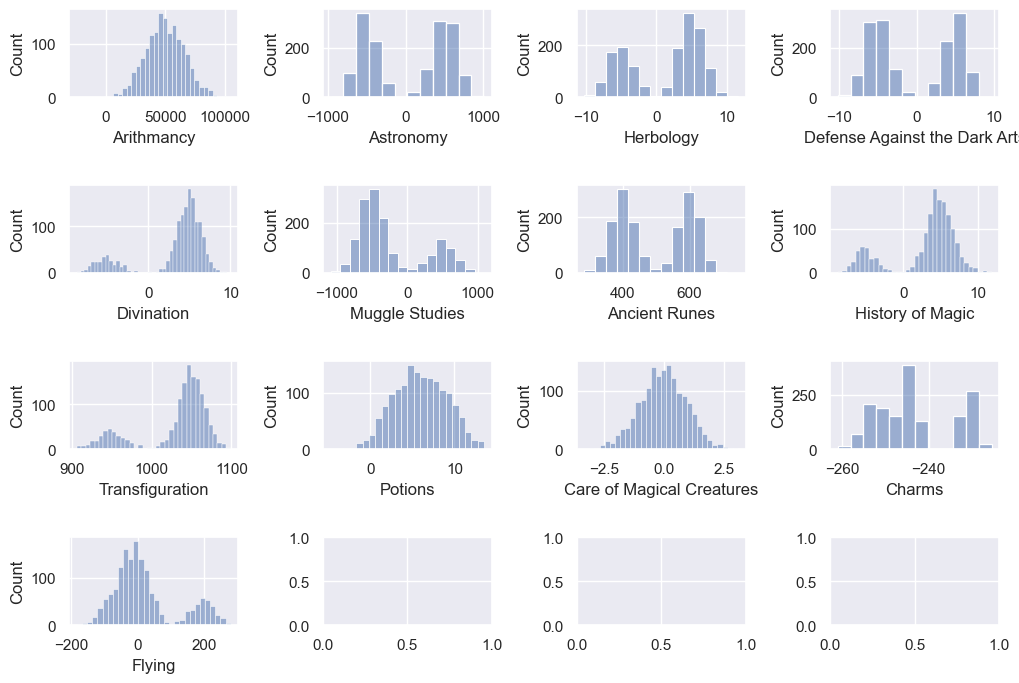

In [111]:
fig, ax = plt.subplots(4 , 4, figsize=(12, 8))
for i, course in enumerate(courses):
    sns.histplot(data[course], ax=ax[i // 4][i % 4], alpha=0.5)
    plt.subplots_adjust(hspace=1, wspace=0.5)
plt.show()

In [112]:
normalized_data = (data[courses] - data[courses].mean()) / data[courses].std()
normalized_data

,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
0,0.524552,-1.014194,0.878628,1.010346,0.377371,1.021139,0.345639,0.512444,0.219633,-0.686183,0.791972,1.204553,-0.500330
1,1.055434,-1.137535,-1.365690,1.133455,-2.109573,-0.540256,-1.204191,0.258503,0.653769,0.412462,0.149365,-1.002983,-1.386928
2,-1.554729,-0.780078,1.261379,0.776671,0.718622,1.828915,1.005195,0.133871,1.314249,0.882556,-0.475471,1.825184,0.086673
3,-1.017252,1.264555,-1.463352,-1.264114,0.209874,-0.642366,0.265645,-1.756242,-2.486237,-1.629193,0.040544,-1.533799,1.830165
4,0.630908,0.762982,-1.716894,NaN,-0.220901,-0.451681,0.974516,-1.447763,-2.099988,-0.520770,-0.216832,-1.481492,1.393217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,-0.037505,0.604428,-1.088736,-0.605230,0.613214,-0.560600,1.152299,-1.851612,-1.492961,-0.813661,-0.614084,-0.799168,1.678473
1596,0.819040,0.629896,0.942595,-0.630650,-0.336175,-0.860873,-0.469684,-0.163809,0.590376,-0.039745,-0.288777,-0.347553,0.233961
1597,0.855551,0.969101,-0.832290,-0.969217,0.700573,-0.330137,1.312164,-2.021646,-1.727593,-1.347129,0.128669,-0.940656,1.807939
1598,1.983142,0.795465,0.440987,-0.795907,0.862534,-1.248397,-1.056620,0.192060,1.311096,-0.650053,-0.492505,-0.320631,-1.011640


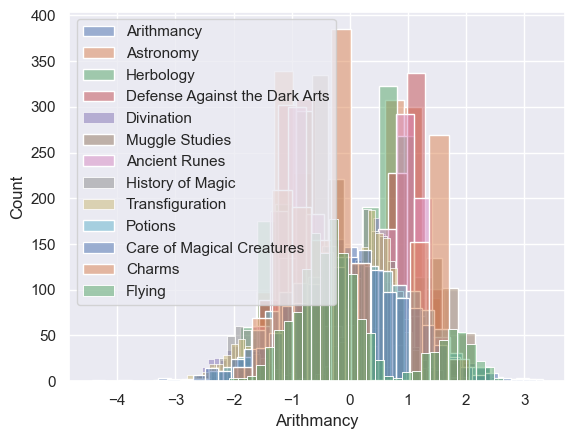

In [113]:
for course in courses:
  sns.histplot(normalized_data[course], alpha=0.5, label=course)
plt.legend()
plt.show()

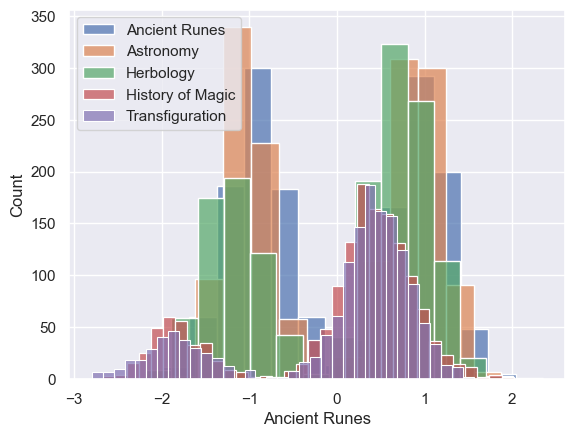

In [114]:
attributes = ['Ancient Runes', 'Astronomy', 'Herbology', 'History of Magic', 'Transfiguration']
for attr in attributes:
    sns.histplot(normalized_data[attr], alpha=0.7, label=attr)
plt.legend()
plt.show()

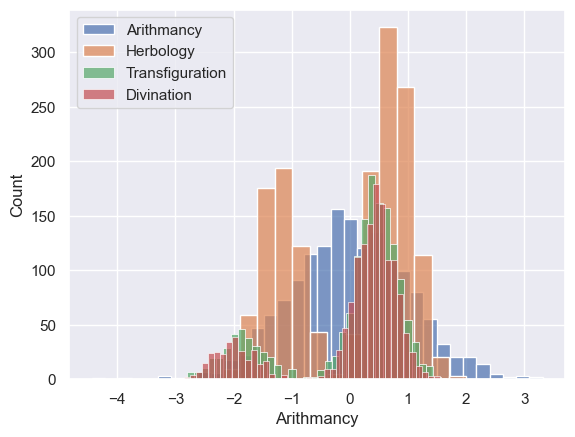

In [115]:
attributes = ['Arithmancy', 'Herbology', 'Transfiguration', 'Divination']
for attr in attributes:
    sns.histplot(normalized_data[attr], alpha=0.7, label=attr)
plt.legend()
plt.show()

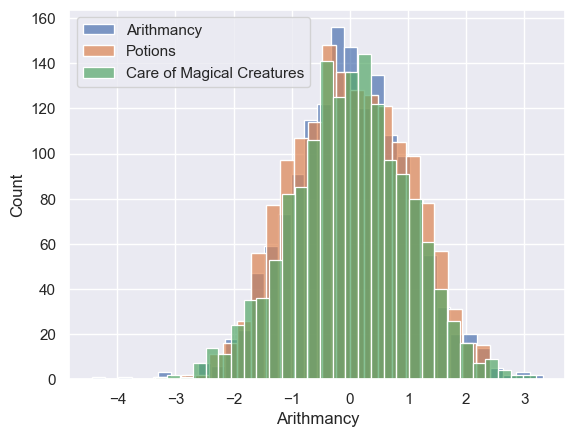

In [116]:
attributes = ['Arithmancy', 'Potions', 'Care of Magical Creatures']
for attr in attributes:
    sns.histplot(normalized_data[attr], alpha=0.7, label=attr)
plt.legend()
plt.show()